In [14]:
import builtins
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Restore builtins that may have been shadowed by earlier exploratory cells
str   = builtins.str
int   = builtins.int
float = builtins.float
list  = builtins.list

In [15]:
df = pd.read_csv("output/ebay_listing_details.csv")
df.head()

,listing_url,title,category,subcategory,brand,condition,description,description_length,image_count,seller_name,listing_date_text,item_number,location,detail_scraped_at,raw_item_specifics_json,detail_error
0,https://www.ebay.com/itm/366374202994,Apple iPhone 13 Pro Sierra Blue 128GB Unlocked,NaN,NaN,"{'@type': 'Brand', 'name': 'Apple'}",NaN,Perfect condition no dents no scratches Unlock...,85.0,67.0,dehlscar_0,"This Buy It Now listing sold on Tue, Apr 28 at...",3.663742e+11,NaN,2026-04-28T09:14:06.233763+00:00,"{""this buy it now listing sold on tue, apr 28 ...",NaN
1,https://www.ebay.com/itm/177959360090,"Apple iPhone SE (2nd Generation) 64GB, Black, ...",NaN,NaN,"{'@type': 'Brand', 'name': 'Apple'}",NaN,Selling my old iPhone SE. The phone is in grea...,209.0,87.0,3634ramon,"This listing sold on Tue, Apr 28 at 1:34 AM.",1.779594e+11,NaN,2026-04-28T09:14:12.373359+00:00,"{""this listing sold on tue, apr 28 at 1"": ""34 ...",NaN
2,https://www.ebay.com/itm/306901428315,Apple iPhone 11 - 128 GB - White (Unlocked),NaN,NaN,NaN,NaN,Find many great new & used options and get the...,173.0,81.0,NaN,NaN,NaN,NaN,2026-04-28T09:14:17.492653+00:00,"{""returns"": ""No returns, but backed by eBay Mo...",NaN
3,https://www.ebay.com/itm/277855390048,*FMI ON/Activation* iPhone 14 - 128 GB RED Unl...,NaN,NaN,"{'@type': 'Brand', 'name': 'Apple'}",NaN,FMI - ON.iCloud activation BYPASSED. Cellular ...,282.0,75.0,sherrjosep835,"This listing was ended by the seller on Tue, A...",2.778554e+11,NaN,2026-04-28T09:14:24.078167+00:00,"{""this listing was ended by the seller on tue,...",NaN
4,https://www.ebay.com/itm/146925166774,✅Apple iPhone 13 128GB Midnight Black [Good] [...,NaN,NaN,"{'@type': 'Brand', 'name': 'Apple'}",NaN,Storage: 128GB. Carrier: Fully Unlocked. Genui...,183.0,79.0,PC LiQUIDATION Store,"This listing sold on Tue, Apr 28 at 1:31 AM.",1.469252e+11,NaN,2026-04-28T09:14:31.034026+00:00,"{""this listing sold on tue, apr 28 at 1"": ""31 ...",NaN


In [16]:
# ── Quick EDA snapshot ──
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nNumeric columns: {df.select_dtypes(include=[np.number]).columns.tolist()}")
print(f"\nCategorical columns: {df.select_dtypes(include=['object']).columns.tolist()}")
print(f"\nDescriptive statistics:")
df.describe().round(2)

DATASET SUMMARY

Shape: 10,000 rows × 16 columns

Numeric columns: ['category', 'subcategory', 'description_length', 'image_count', 'item_number', 'location']

Categorical columns: ['listing_url', 'title', 'brand', 'condition', 'description', 'seller_name', 'listing_date_text', 'detail_scraped_at', 'raw_item_specifics_json', 'detail_error']

Descriptive statistics:


/var/folders/hq/v_7wt_d51sn37zqs9vlsf41c0000gn/T/ipykernel_99763/1316663771.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"\nCategorical columns: {df.select_dtypes(include=['object']).columns.tolist()}")


,category,subcategory,description_length,image_count,item_number,location
count,0.0,0.0,8925.00,8925.00,7.889000e+03,0.0
mean,NaN,NaN,229.91,75.89,2.687211e+11,NaN
std,NaN,NaN,161.34,37.14,9.295266e+10,NaN
min,NaN,NaN,0.00,0.00,1.118974e+11,NaN
25%,NaN,NaN,124.00,52.00,1.857199e+11,NaN
50%,NaN,NaN,202.00,75.00,2.777241e+11,NaN
75%,NaN,NaN,259.00,95.00,3.584476e+11,NaN
max,NaN,NaN,799.00,1441.00,4.068898e+11,NaN


## Column Descriptions

| Column | Type | Description |
|---|---|---|
| `listing_url` | str | Full eBay listing page URL; used as a unique row key |
| `title` | str | Raw listing title as shown on eBay; primary text feature for embeddings and keyword extraction |
| `category` | float64 | Top-level category scraped from eBay breadcrumb — empty in this scrape (0 non-null); derived later via keyword/brand rules |
| `subcategory` | float64 | Sub-level category from breadcrumb — empty in this scrape; derived alongside `category` |
| `brand` | str | Brand info serialised as a JSON dict `{"name": "..."}` from eBay item specifics; parsed by `extract_brand()` |
| `condition` | str | Item condition string (e.g. "New", "Used — Like New"); very sparse here — filled from `raw_item_specifics_json` in preprocessing |
| `description` | str | Full item description as plain text; used for keyword fallback and description length feature |
| `description_length` | float64 | Character count of `description`; proxy for listing effort / seller quality |
| `image_count` | float64 | Number of images attached to the listing; higher counts correlate with better-priced items |
| `seller_name` | str | eBay seller username; not used as a model feature directly but useful for deduplication |
| `listing_date_text` | str | Raw listing date string as scraped (e.g. "Listed 12 Sep, 2024"); parsed to derive `days_listed` |
| `item_number` | float64 | eBay's unique numeric listing ID; useful for deduplication and future API lookups |
| `location` | float64 | Seller location — empty in this scrape (0 non-null); would encode postcode region if available |
| `detail_scraped_at` | str | ISO timestamp of when the detail page was fetched; used to detect stale rows |
| `raw_item_specifics_json` | str | Full eBay "Item Specifics" table serialised as JSON; source of truth for condition, brand, model year, storage, colour, etc. |
| `detail_error` | str | Error message if detail-page scrape failed (e.g. timeout, 404); `NaN` on success — rows with errors lack most detail columns |

In [17]:
# Count nulls per column and express as a percentage of total rows
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

# Combine into a single table and show only columns that have at least one missing value
missing_df = pd.DataFrame({"Missing": missing, "% Missing": missing_pct})
missing_df[missing_df["Missing"] > 0].sort_values("% Missing", ascending=False)

,Missing,% Missing
category,10000,100.00
subcategory,10000,100.00
location,10000,100.00
condition,9998,99.98
detail_error,8925,89.25
listing_date_text,3351,33.51
brand,2564,25.64
seller_name,2111,21.11
item_number,2111,21.11
title,1193,11.93


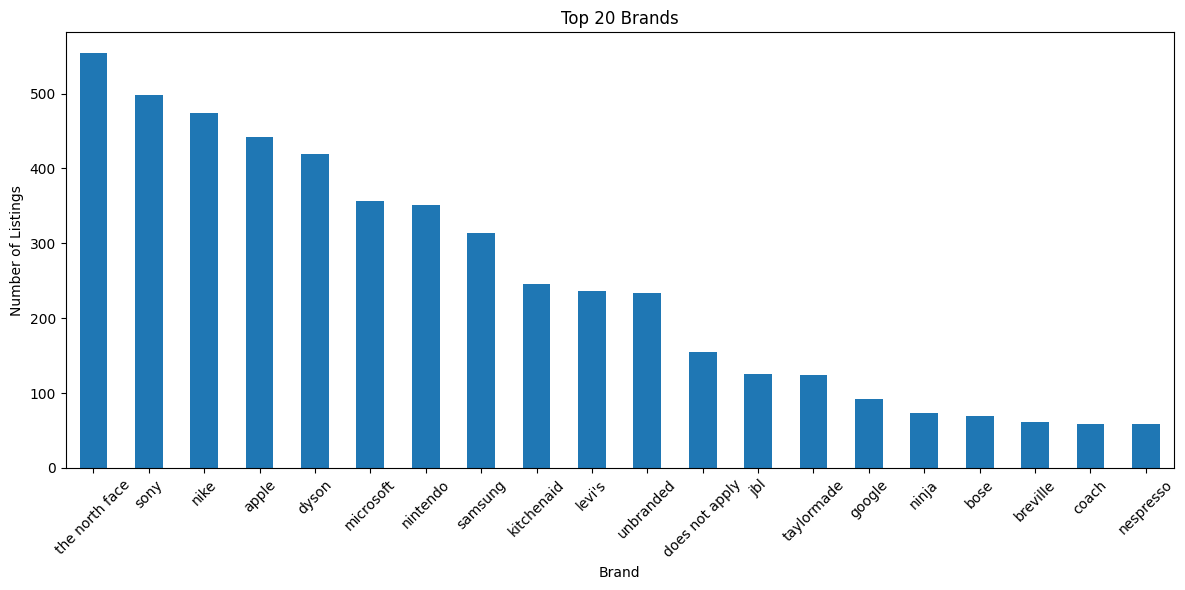

brand_name
the north face    7.450242
sony              6.697149
nike              6.374395
apple             5.944056
dyson             5.634750
microsoft         4.787520
nintendo          4.720280
samsung           4.222700
kitchenaid        3.308230
levi's            3.173749
unbranded         3.133405
does not apply    2.084454
jbl               1.681011
taylormade        1.667563
google            1.237224
ninja             0.995159
bose              0.927918
breville          0.833782
coach             0.793437
nespresso         0.793437
Name: count, dtype: float64


In [18]:
import ast
import pandas as pd
import matplotlib.pyplot as plt

def extract_brand(x):
    if pd.isna(x):
        return None
    if hasattr(x, 'as_py'):
        x = x.as_py()
    if x is None:
        return None
    try:
        parsed = ast.literal_eval(str(x))
        return (parsed.get("name") or "").lower() or None
    except Exception:
        return str(x).lower() or None

df["brand_name"] = df["brand"].apply(extract_brand)

brand_series = df["brand_name"].value_counts()

brand_series.head(20).plot(kind="bar", figsize=(12, 6))
plt.title("Top 20 Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

brand_proportion = (brand_series / brand_series.sum()) * 100
print(brand_proportion.head(20))

In [19]:
import re

# --- 1. CLEANING FUNCTION ---
def clean_brand(brand):
    if pd.isna(brand) or str(brand).lower() in ["", "nan", "none", "unbranded", "branded"]:
        return "unbranded"
    brand = str(brand).lower()
    brand = re.sub(r"[®™©]", "", brand)
    brand = re.sub(r"\b(inc|corp|co|ltd|official store|store|brand)\b", "", brand)
    return brand.strip()

# --- 2. BRAND → CATEGORY MAP ---
CATEGORY_RULES = {
    "electronics": [
        "apple", "samsung", "sony", "lg", "motorola", "nokia", "htc", "xiaomi", "oppo",
        "google", "microsoft", "asus", "acer", "dell", "hp", "lenovo", "beats", "bose",
        "jbl", "anker", "fitbit", "dyson", "ultimate ears", "soundcore", "harman kardon",
        "marshall", "uniwa", "kyocera", "oneplus", "razer", "logitech", "corsair",
        "turtlebox", "sonos", "tribit", "ue boom", "pantech", "tcl", "wiko",
    ],
    "fashion": [
        "gucci", "prada", "louis vuitton", "chanel", "dior", "balenciaga", "versace",
        "fendi", "burberry", "tory burch", "zara", "h&m", "uniqlo", "nike", "adidas",
        "puma", "levis", "ralph lauren", "tommy hilfiger", "coach", "michael kors",
        "wrangler", "dooney & bourke", "jordan", "guess", "carhartt", "north face",
        "columbia", "patagonia", "under armour", "lululemon", "fossil", "ray-ban",
        "oakley", "vans", "converse", "new balance", "reebok", "timberland",
    ],
    "gaming": [
        "playstation", "xbox", "nintendo", "atari", "sega", "activision", "ea sports",
        "ubisoft", "thq", "valve", "turbografx",
    ],
    "luxury": ["hermes", "cartier", "rolex", "bvlgari", "chopard", "omega", "tag heuer"],
    "home_kitchen": [
        "kitchenaid", "breville", "delonghi", "cuisinart", "ninja", "instant pot",
        "keurig", "philips", "miele", "nespresso", "gourmia", "chefman", "presto",
        "bella", "whirlpool", "jura", "cosori", "outin", "mr. coffee", "shark",
        "roomba", "irobot", "waring", "pavoni", "gaggia",
    ],
    "sports": [
        "callaway", "taylormade", "titleist", "ping", "wilson", "bridgestone", "mizuno",
        "cleveland", "cobra", "odyssey", "scotty cameron", "footjoy", "srixon",
        "polaris", "acdelco",
    ],
}

# --- 3. TITLE/DESCRIPTION KEYWORD MAP ---
ITEM_KEYWORDS = {
    "electronics": [
        # Phones — "android" and "phone" are safe single words in eBay product context
        "iphone", "ipad", "macbook", "airpods", "galaxy s", "galaxy a", "galaxy tab",
        "pixel phone", "pixel watch", "smartphone", "android phone", "android",
        "dual sim", "unlocked phone", "prepaid phone", "flip phone", "5g phone",
        "cell phone", "lte phone",
        # Audio
        "bluetooth speaker", "portable speaker", "wireless speaker", "waterproof speaker",
        "outdoor speaker", "stereo speaker", "speaker system", "bocina",
        "earbuds", "earphones", "headphones", "soundbar", "subwoofer", "boombox",
        # Computing / accessories
        "smartwatch", "fitness tracker", "smart tv", "laptop", "chromebook",
        "gaming laptop", "tablet pc", "e-reader", "kindle", "gopro",
        "keyboard", "mechanical keyboard", "usb hub", "charging dock",
    ],
    "gaming": [
        "playstation", "ps5", "ps4", "ps3", "ps vita", "xbox one", "xbox series",
        "nintendo switch", "nintendo 3ds", "game boy", "gamecube", "wii",
        "gaming console", "retro console", "handheld console", "analogue pocket",
        "video game", "pc game", "steam deck",
    ],
    "fashion": [
        "jeans", "hoodie", "tracksuit", "joggers", "leggings", "jacket", "blazer",
        "cardigan", "blouse", "dress", "sneakers", "trainers", "boots", "heels",
        "handbag", "tote bag", "crossbody bag", "backpack", "purse", "wallet",
        "sunglasses", "belt", "scarf",
    ],
    "home_kitchen": [
        "espresso machine", "coffee maker", "air fryer", "slow cooker", "instant pot",
        "pressure cooker", "stand mixer", "rice cooker", "waffle maker", "toaster",
        "microwave oven", "vacuum cleaner", "robot vacuum", "steam mop",
        "food processor", "blender", "juicer", "electric kettle",
        # "fryer" alone is safe — covers "Digital Fryer", "Deep Fryer" without "air" prefix
        "fryer", "deep fryer",
    ],
    "sports": [
        "golf club", "golf bag", "golf balls", "golf rangefinder", "golf glove",
        "golf shoes", "golf cart", "putting mat", "swing trainer",
        "golf driver", "fairway wood", "iron set", "golf wedge",
        # Bare terms — word cloud shows these appear without "golf" prefix in titles
        "putter", "wedge", "golf grip", "shaft graphite", "shaft stiff",
        "tennis racket", "football boots", "cycling helmet", "yoga mat", "dumbbell",
        "weight plate", "resistance band", "treadmill", "exercise bike",
    ],
    "books": [
        "hardcover", "paperback", "novel", "textbook", "first edition", "signed copy",
        "graphic novel", "manga", "comic book", "book set", "box set books",
    ],
    "collectibles": [
        "trading card", "pokemon card", "magic the gathering", "sports card",
        "action figure", "funko pop", "diecast model", "vintage toy",
        "signed memorabilia", "limited edition", "rare collectible",
    ],
}

BRAND_MAP = {brand: cat for cat, brands in CATEGORY_RULES.items() for brand in brands}

In [20]:
print(set(df['brand_name'].tolist()))

{'liz claiborne', 'montana west', 'upspec gaming', 'microsoft, konami, ea sports, atari, namco', 'mc', 'pepe co.', 'juson wearables', 'cobra golf', 'cherokee', 'bomber', 'riviera', 'silvertab', 'presto', 'umidigi', 'power', 'iqoo', 'speakers', 'powerxl', 'pro elite', 'univen', 'ami', 'square strike', 'converse', 'joseph hess', 'marc jacobs', 'porsche', 'hiroshi kato', 'playstation, sony, squaresoft, namco, activision', 'eddie bauer', 'boribim', 'maze speed', 'bvlgari', 'sanfor', 'maurizio taiuti', 'xbox', 'jbl by harman', 'nespresso', 'owanz', 'minirig', 'caribbean joe', 'sam edelman', 'timberland', 'attrak', 'scaroo', 'amazfit', 'orslow', 'alessi', 'mario hernandez', 'beaterblade', 'webs jeans', 'marlboro country store', 'vera bradley', 'master 5000', 'brighton', 'maxlife®', 'sakroots', 'schaefer outfitter', 'whall', 'ambassador', 'perlina', 'bella pro', 'bellman', 'valley co', 'loungefly', 'montgomery ward company', 'dash', 'koltov', 'fkbym', 'hollister', 'alcatel', 'jean pierre', 'r

category
electronics     3448
fashion         2310
home_kitchen    1664
other           1374
gaming           693
sports           509
collectibles       1
luxury             1
Name: count, dtype: int64

category
electronics     34.5%
fashion         23.1%
home_kitchen    16.6%
other           13.7%
gaming           6.9%
sports           5.1%
collectibles     0.0%
luxury           0.0%
Name: proportion, dtype: str


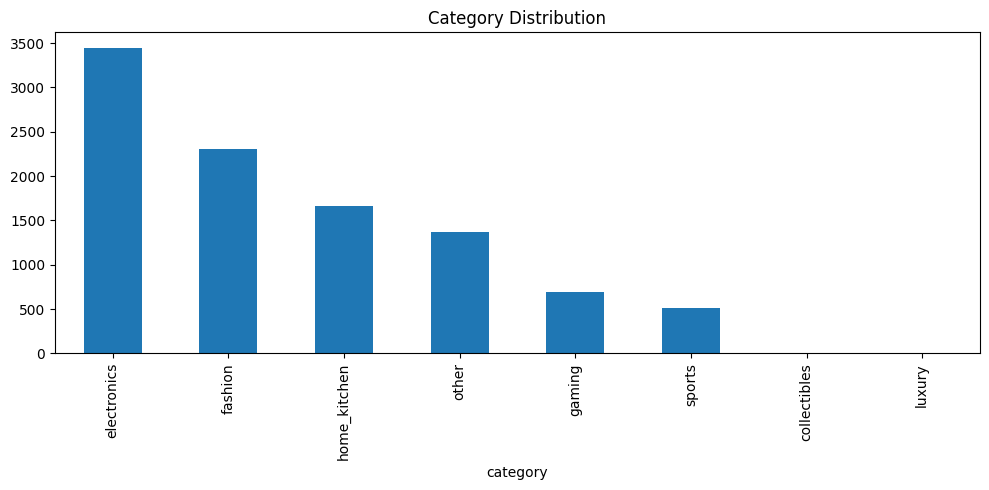

In [21]:
def assign_category_final(row):
    title_txt = str(row['title']).lower() if pd.notna(row['title']) else ""
    desc_txt  = str(row['description']).lower() if pd.notna(row['description']) else ""
    # brand_name is already a clean lowercase string extracted by extract_brand()
    brand_name = str(row['brand_name']).lower() if pd.notna(row['brand_name']) else ""

    # 1. Extracted brand column → BRAND_MAP (highest confidence)
    if brand_name and brand_name not in ("nan", "none", "unbranded", ""):
        cat = BRAND_MAP.get(brand_name)
        if cat:
            return cat

    # 2. Any known brand name found inside the listing title
    #    catches "Apple iPhone 13 Pro" when brand column is empty
    for brand, cat in BRAND_MAP.items():
        if brand in title_txt:
            return cat

    # 3. Keyword scan of title + description
    combined = title_txt + " " + desc_txt
    if combined.strip():
        for cat, keywords in ITEM_KEYWORDS.items():
            if any(k in combined for k in keywords):
                return cat

    return "other"

df["brand_clean"] = df["brand_name"].apply(lambda x: clean_brand(x) if pd.notna(x) else "unbranded")
df["category"] = df.apply(assign_category_final, axis=1)

print(df["category"].value_counts())
print()
print(df["category"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")

df["category"].value_counts().plot(kind="bar", figsize=(10, 5))
plt.title("Category Distribution")
plt.tight_layout()
plt.show()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4109.52it/s]


Starting 'other' count: 1,374


Batches: 100%|██████████| 11/11 [00:00<00:00, 52.36it/s]


After title pass: 1,151 still 'other' — trying description...


Batches: 100%|██████████| 9/9 [00:00<00:00, 15.23it/s]


After description pass: 1,107 still 'other'

category
electronics     3483
fashion         2338
home_kitchen    1774
other           1107
gaming           720
sports           537
luxury            27
collectibles      12
books              2
Name: count, dtype: int64

category
electronics     34.8%
fashion         23.4%
home_kitchen    17.7%
other           11.1%
gaming           7.2%
sports           5.4%
luxury           0.3%
collectibles     0.1%
books            0.0%
Name: proportion, dtype: str


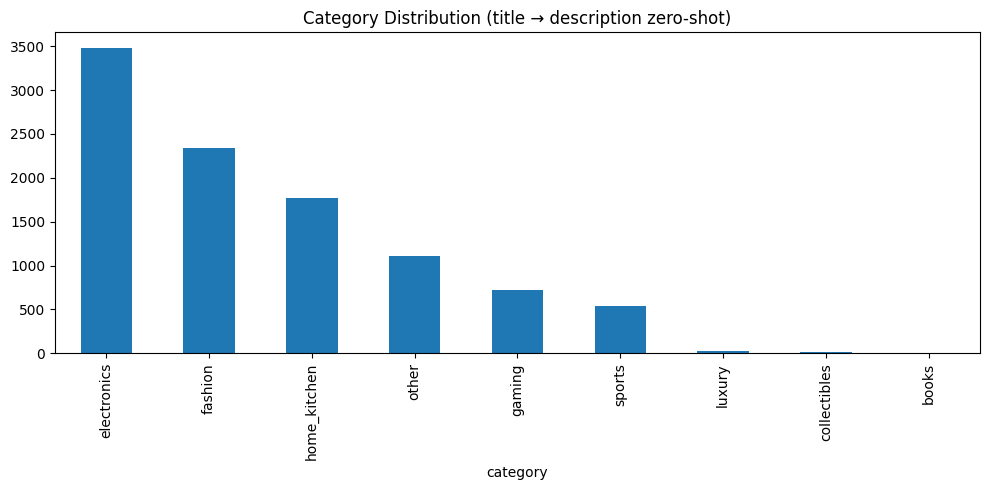

In [22]:
from sentence_transformers import SentenceTransformer, util
import torch
import numpy as np

CATEGORY_DESCRIPTIONS = {
    "electronics":   "bluetooth speaker portable speaker wireless speaker waterproof speaker outdoor speaker, smartphones iphones android phones unlocked phone dual sim, laptops macbooks tablets ipads earbuds airpods headphones earphones smartwatches fitness trackers cameras drones e-readers kindle soundbar boombox",
    "gaming":        "video game consoles PlayStation Xbox Nintendo Switch game boy retro consoles handheld gaming video games PC games steam deck gaming accessories controllers",
    "fashion":       "clothing jeans hoodies jackets dresses sneakers trainers boots shoes handbags purses wallets sunglasses sportswear streetwear designer clothing accessories backpack",
    "home_kitchen":  "kitchen appliances coffee machines espresso makers air fryers slow cookers stand mixers vacuum cleaners robot vacuums toasters microwaves blenders food processors electric kettles fryer deep fryer",
    "sports":        "golf clubs putter wedge driver fairway wood iron set golf bags golf balls tennis rackets football boots cycling gear gym equipment dumbbells treadmills exercise bikes yoga mats fitness equipment golf grip shaft",
    "books":         "books novels hardcover paperback textbooks first edition graphic novels manga comic books box set signed books children books",
    "collectibles":  "trading cards pokemon cards sports cards action figures funko pop diecast models vintage toys signed memorabilia stamps coins limited edition rare collectibles",
    "luxury":        "luxury watches rolex omega designer handbags fine jewellery diamond rings high-end fashion accessories premium goods",
}

THRESHOLD = 0.22

model      = SentenceTransformer("all-MiniLM-L6-v2")
cat_names  = list(CATEGORY_DESCRIPTIONS.keys())
cat_embeds = model.encode(list(CATEGORY_DESCRIPTIONS.values()),
                          convert_to_tensor=True, normalize_embeddings=True)

def zero_shot_pass(texts, label=""):
    embeds = model.encode(texts, convert_to_tensor=True, normalize_embeddings=True,
                          batch_size=128, show_progress_bar=bool(label))
    sims   = util.cos_sim(embeds, cat_embeds)
    return sims.argmax(dim=1).cpu().numpy(), sims.max(dim=1).values.cpu().numpy()

# ── Stage 1: classify on title ────────────────────────────────────────────────
other_mask = df["category"] == "other"
print(f"Starting 'other' count: {other_mask.sum():,}")

titles    = df.loc[other_mask, "title"].fillna("").astype(str).tolist()
idx1, sc1 = zero_shot_pass(titles, label="Stage 1 — title")

assigned1 = [cat_names[i] if s >= THRESHOLD else "other" for i, s in zip(idx1, sc1)]
df.loc[other_mask, "category"] = assigned1

# ── Stage 2: fall back to description for still-unclassified rows ─────────────
other_mask2 = df["category"] == "other"
print(f"After title pass: {other_mask2.sum():,} still 'other' — trying description...")

descs = (df.loc[other_mask2, "description"]
           .fillna("")
           .astype(str)
           .str.split()
           .str[:100]
           .str.join(" ")
           .tolist())

idx2, sc2 = zero_shot_pass(descs, label="Stage 2 — description")

assigned2 = [cat_names[i] if s >= THRESHOLD else "other" for i, s in zip(idx2, sc2)]
df.loc[other_mask2, "category"] = assigned2

# ── Results ───────────────────────────────────────────────────────────────────
print(f"After description pass: {(df['category'] == 'other').sum():,} still 'other'\n")
print(df["category"].value_counts())
print()
print(df["category"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")

df["category"].value_counts().plot(kind="bar", figsize=(10, 5))
plt.title("Category Distribution (title → description zero-shot)")
plt.tight_layout()
plt.show()

In [23]:
import re
from wordcloud import STOPWORDS

other_mask = df['category'] == 'other'

text      = ' '.join(str(t) for t in df.loc[other_mask, 'title'].fillna(''))
#desc_text = ' '.join(str(t) for t in df.loc[other_mask, 'description'].fillna(''))
#text += ' ' + desc_text

text = re.sub(r'[^A-Za-z\s]', '', text).lower()

stopwords = set(STOPWORDS)
text = ' '.join(word for word in text.split() if word not in stopwords)

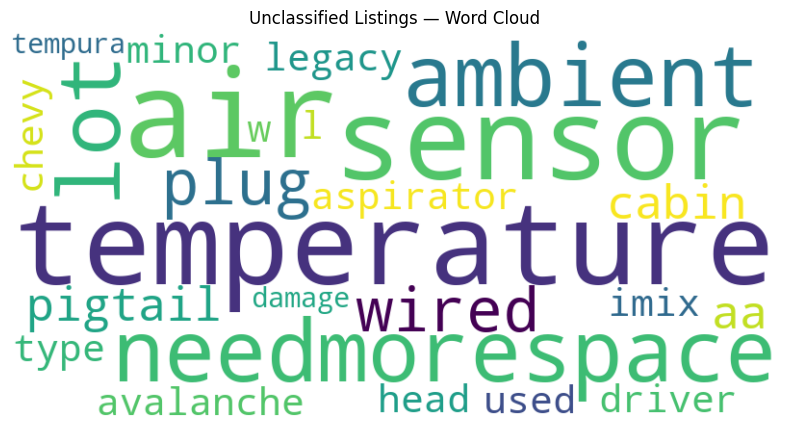

In [24]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Unclassified Listings — Word Cloud")
plt.show()

In [25]:
from sklearn.linear_model import LinearRegression

# Only real numeric features available at this stage — VIF on the full
# engineered feature matrix should be re-run in the preprocessing notebook.
numerical_cols = ["description_length", "image_count"]

def calculate_vif(df, features):
    """VIF_i = 1 / (1 - R²_i), R²_i from regressing feature_i on all others."""
    vif_data = []
    X = df[features].to_numpy(dtype=float)

    for i, feat in enumerate(features):
        X_other = np.delete(X, i, axis=1)
        y_feat  = X[:, i]

        mask = ~np.isnan(y_feat) & ~np.any(np.isnan(X_other), axis=1)
        if mask.sum() < 10:
            vif_data.append({"Feature": feat, "VIF": np.nan, "R²": np.nan})
            continue

        lr = LinearRegression()
        lr.fit(X_other[mask], y_feat[mask])
        r2  = lr.score(X_other[mask], y_feat[mask])
        vif = 1 / (1 - r2) if r2 < 1 else float("inf")
        vif_data.append({"Feature": feat, "VIF": round(vif, 2), "R²": round(r2, 4)})

    return pd.DataFrame(vif_data).sort_values("VIF", ascending=False)


vif_df = calculate_vif(df, df.select_dtypes(include=[np.number]).columns.tolist())
vif_df["Status"] = vif_df["VIF"].apply(
    lambda x: "VERY HIGH (>10)" if x > 10 else
              "HIGH (5-10)"     if x > 5  else
              "MODERATE (2-5)"  if x > 2  else
              "LOW (<2)"
)

print("VARIANCE INFLATION FACTOR ANALYSIS")
print("=" * 70)
print(vif_df.to_string(index=False))
print("\nNote: only 2 raw numeric features exist pre-preprocessing.")
print("Re-run on the full feature matrix in the preprocessing notebook.")

VARIANCE INFLATION FACTOR ANALYSIS
           Feature  VIF  R²   Status
       subcategory  NaN NaN LOW (<2)
description_length  NaN NaN LOW (<2)
       image_count  NaN NaN LOW (<2)
       item_number  NaN NaN LOW (<2)
          location  NaN NaN LOW (<2)

Note: only 2 raw numeric features exist pre-preprocessing.
Re-run on the full feature matrix in the preprocessing notebook.


Rows with price data: 8,893

Price summary by category (USD):
              count  median    mean     std    p25     p75      max
category                                                           
electronics    3483  175.00  226.51  246.96  69.95  329.99  4299.00
sports          537  124.00  182.15  207.43  55.99  219.99  2000.00
gaming          720  119.99  143.05  168.47  45.00  173.87  3000.00
luxury           27   74.99   95.75   76.51  37.35  143.86   319.99
home_kitchen   1774   69.99  153.19  313.00  29.99  178.24  6200.00
collectibles     12   55.00  134.68  191.99  25.71  173.49   700.00
fashion        2338   42.00   77.60  185.36  25.00   79.94  5999.98
books             2   31.49   31.49   12.02  27.24   35.74    39.99


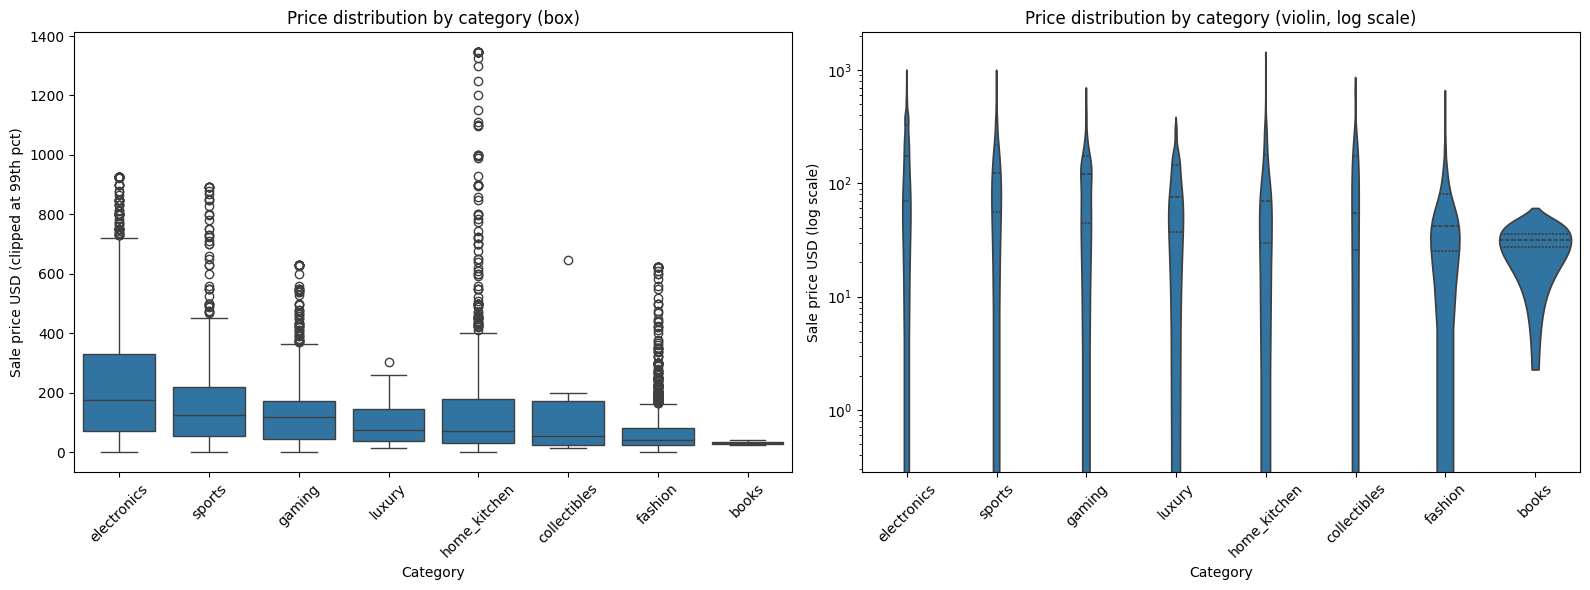

In [26]:
import seaborn as sns

# ── Price distribution per category ──────────────────────────────────────────
price_df = pd.read_csv(
    "output/ebay_playwright_features.csv",
    usecols=["listing_url", "sale_price", "currency"],
)

cat_price = (
    df[["listing_url", "category"]]
    .merge(price_df, on="listing_url", how="inner")
    .query("category != 'other' and sale_price > 0")
)

# Clip per-category at 99th percentile so outliers don't flatten the plots
cat_price["sale_price_clipped"] = cat_price.groupby("category")["sale_price"].transform(
    lambda s: s.clip(upper=s.quantile(0.99))
)

print(f"Rows with price data: {len(cat_price):,}\n")

# ── Summary statistics ────────────────────────────────────────────────────────
summary = (
    cat_price.groupby("category")["sale_price"]
    .agg(
        count="count",
        median="median",
        mean="mean",
        std="std",
        p25=lambda s: s.quantile(0.25),
        p75=lambda s: s.quantile(0.75),
        max="max",
    )
    .round(2)
    .sort_values("median", ascending=False)
)
print("Price summary by category (USD):")
print(summary.to_string())

order = summary.index.tolist()

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=cat_price, x="category", y="sale_price_clipped",
    order=order, ax=axes[0],
)
axes[0].set_title("Price distribution by category (box)")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Sale price USD (clipped at 99th pct)")
axes[0].tick_params(axis="x", rotation=45)

sns.violinplot(
    data=cat_price, x="category", y="sale_price_clipped",
    order=order, ax=axes[1], inner="quartile",
)
axes[1].set_yscale("log")
axes[1].set_title("Price distribution by category (violin, log scale)")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Sale price USD (log scale)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

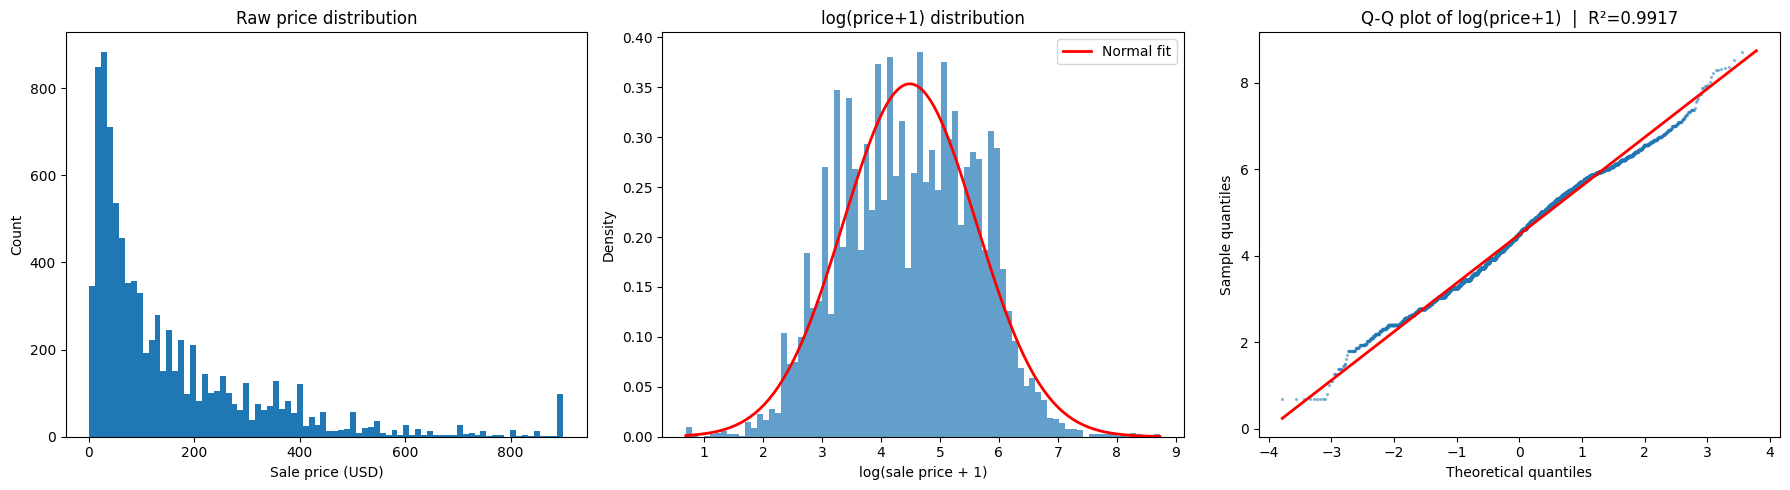

Shapiro-Wilk on log(price+1) sample (n=5,000): W=0.9915, p=0.0000

Skewness — raw price: 8.97   log(price+1): -0.03

log(price+1) is approximately normal → train XGBoost on log(price+1), exponentiate predictions.


In [27]:
from scipy import stats

prices = cat_price["sale_price"].dropna()
log_prices = np.log1p(prices)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Raw price histogram ───────────────────────────────────────────────────────
axes[0].hist(prices.clip(upper=prices.quantile(0.99)), bins=80, edgecolor="none")
axes[0].set_title("Raw price distribution")
axes[0].set_xlabel("Sale price (USD)")
axes[0].set_ylabel("Count")

# ── Log price histogram with normal curve overlay ─────────────────────────────
mu, sigma = log_prices.mean(), log_prices.std()
x = np.linspace(log_prices.min(), log_prices.max(), 200)
axes[1].hist(log_prices, bins=80, density=True, edgecolor="none", alpha=0.7)
axes[1].plot(x, stats.norm.pdf(x, mu, sigma), "r-", linewidth=2, label="Normal fit")
axes[1].set_title("log(price+1) distribution")
axes[1].set_xlabel("log(sale price + 1)")
axes[1].set_ylabel("Density")
axes[1].legend()

# ── Q-Q plot ──────────────────────────────────────────────────────────────────
(osm, osr), (slope, intercept, r) = stats.probplot(log_prices, dist="norm")
axes[2].scatter(osm, osr, s=2, alpha=0.4)
axes[2].plot(
    [osm[0], osm[-1]],
    [slope * osm[0] + intercept, slope * osm[-1] + intercept],
    "r-", linewidth=2,
)
axes[2].set_title(f"Q-Q plot of log(price+1)  |  R²={r**2:.4f}")
axes[2].set_xlabel("Theoretical quantiles")
axes[2].set_ylabel("Sample quantiles")

plt.tight_layout()
plt.show()

# ── Shapiro-Wilk on a sample (test breaks down on large N) ────────────────────
sample = log_prices.sample(min(5000, len(log_prices)), random_state=42)
stat, p = stats.shapiro(sample)
print(f"Shapiro-Wilk on log(price+1) sample (n={len(sample):,}): W={stat:.4f}, p={p:.4f}")
print()
skew_raw = float(prices.skew())
skew_log = float(log_prices.skew())
print(f"Skewness — raw price: {skew_raw:.2f}   log(price+1): {skew_log:.2f}")
print()
if abs(skew_log) < 1:
    print("log(price+1) is approximately normal → train XGBoost on log(price+1), exponentiate predictions.")
else:
    print("log(price+1) still skewed — consider further transformation or train on raw price with quantile loss.")

# Preprocessing

Steps performed before feature engineering:
1. Merge `sale_price` onto the main dataframe
2. Filter invalid rows (failed scrapes, missing title, no price, unclassified)
3. Deduplicate on `listing_url`
4. Extract `condition` from `raw_item_specifics_json` (source column is 99.98% null)
5. Clip price outliers per category at 99th percentile
6. Save clean checkpoint to parquet

In [ ]:
# ── Step 1: Merge sale_price ──────────────────────────────────────────────────
price_lookup = pd.read_csv(
    "output/ebay_playwright_features.csv",
    usecols=["listing_url", "sale_price", "currency"],
).drop_duplicates("listing_url")

clean = df.merge(price_lookup, on="listing_url", how="left")
print(f"Rows after merge:            {len(clean):,}")

# ── Step 2: Filter invalid rows ───────────────────────────────────────────────
before = len(clean)

clean = clean[clean["category"] != "other"]
print(f"Dropped 'other' category:    {before - len(clean):,}  →  {len(clean):,} rows")
before = len(clean)

clean = clean[clean["detail_error"].isna()]
print(f"Dropped failed scrapes:      {before - len(clean):,}  →  {len(clean):,} rows")
before = len(clean)

clean = clean[clean["title"].notna()]
print(f"Dropped missing titles:      {before - len(clean):,}  →  {len(clean):,} rows")
before = len(clean)

clean = clean[clean["sale_price"].notna() & (clean["sale_price"] > 0)]
print(f"Dropped missing/zero price:  {before - len(clean):,}  →  {len(clean):,} rows")

# ── Step 3: Deduplicate ───────────────────────────────────────────────────────
before = len(clean)
clean = clean.drop_duplicates(subset="listing_url")
print(f"Dropped duplicate URLs:      {before - len(clean):,}  →  {len(clean):,} rows")

print(f"\nClean dataset: {len(clean):,} rows across {clean['category'].nunique()} categories")
print(clean["category"].value_counts())

In [ ]:
# ── Step 4: Extract condition from raw_item_specifics_json ────────────────────
# The `condition` column is 99.98% null. The condition label is encoded in the
# KEY of the raw JSON, e.g. {"condition new": "A brand-new..."} → "new"

CONDITION_MAP = {
    "new":                        "new",
    "open box":                   "open_box",
    "certified refurbished":      "refurbished",
    "excellent refurbished":      "refurbished",
    "very good refurbished":      "refurbished",
    "good refurbished":           "refurbished",
    "seller refurbished":         "refurbished",
    "used":                       "used",
    "for parts or not working":   "for_parts",
}

def extract_condition(raw_json):
    if pd.isna(raw_json):
        return None
    try:
        d = ast.literal_eval(builtins.str(raw_json))
        for key in d.keys():
            k = key.lower()
            if k.startswith("condition"):
                label = k.replace("condition", "").strip()
                return CONDITION_MAP.get(label, label) if label else None
    except Exception:
        pass
    return None

clean["condition_clean"] = clean["raw_item_specifics_json"].apply(extract_condition)

print("Condition distribution:")
print(clean["condition_clean"].value_counts(dropna=False))
print(f"\nCondition fill rate: {clean['condition_clean'].notna().mean():.1%}")

In [ ]:
# ── Step 5: Clip price outliers per category at 99th percentile ──────────────
p99 = clean.groupby("category")["sale_price"].transform(lambda s: s.quantile(0.99))
before = len(clean)
clean = clean[clean["sale_price"] <= p99].copy()
print(f"Dropped price outliers (above per-category 99th pct): {before - len(clean):,} rows")
print(f"Remaining: {len(clean):,} rows")
print()
print("Price range after clipping:")
print(clean.groupby("category")["sale_price"].agg(["min", "median", "max"]).round(2))

# ── Step 6: Save clean checkpoint ─────────────────────────────────────────────
clean.to_parquet("output/clean.parquet", index=False)
print(f"\nSaved → output/clean.parquet  ({len(clean):,} rows, {clean.shape[1]} columns)")